In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [1]:
from Exoplanet import Exoplanet
from astroquery.mast import Catalogs
import lightkurve
from lightkurve.correctors import DesignMatrix, RegressionCorrector
import numpy

data_paths = []

with open('Exoplanet Discovering/candidate_data_paths.txt', 'r+') as file:
    data_paths.extend([file_name.strip() for file_name in file.readlines()])
    file.seek(0)

for path in data_paths:
    e = Exoplanet.load_from_json(path)

    data = Catalogs.query_object(f'TIC {e.id_num}', catalog = 'TIC')[0]

    host_star = {
        'radius': data['rad'],
        'mass': data['mass'],
        'lum': data['lum'],
        'teff': data['Teff'],
        'logg': data['logg'],
        'ra': data['ra'],
        'dec': data['dec']
    }

    e.add_host_star_attributes(**host_star)

    search_result = lightkurve.search_targetpixelfile(e.host_star['name'], mission = 'TESS', cadence = 'long')
    pixel_files = search_result.download_all(limit = 20)

    collection = lightkurve.LightCurveCollection(None)
    for pixel_file in pixel_files[:]:
        pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
        pixel_file = pixel_file[numpy.isfinite(pixel_file.flux_err).all(axis = (1, 2))]

        aperture_mask = pixel_file.pipeline_mask
        uncorrected_lc = pixel_file.to_lightcurve(aperture_mask = aperture_mask)

        design_matrix = DesignMatrix(pixel_file.flux[:, ~aperture_mask]).pca(5).append_constant()
        lc = RegressionCorrector(uncorrected_lc).correct(design_matrix)
        lc = uncorrected_lc
        lc = lc.normalize().flatten(niters = 10).remove_outliers(10.0)
        collection.append(lc)

    lc = collection.stitch()
    lc = lc.flatten()

    e.calculate_attributes()
    e.calculate_transit_model_params(lc)
    e.make_csv_string()

    print(f'{e.id_num}: {e.impact_parameter}')

    e.to_json(f'Exoplanet Discovering/Paper Materials/Data/{e.host_star['name']} Exoplanet {e.letter}.json')

with open('Exoplanet Discovering/candidate_data_paths.txt', 'r+') as file:
    file.truncate(0)

284611896: nan


295440174: 0.6647442877828295
297701617: 1.208156205359488


300291839: 1.2477621120278126


306635088: 0.9001369999805535
342556321: nan
375477302: 0.7631696711643035
441444256: nan
451596415: 0.8381880971837972


467113954: 0.6898105786157738
734505586: 0.7532190633412189


In [2]:
import os
import json

data = []

for (dirpath, dirnames, filenames) in os.walk('Exoplanet Discovering/Paper Materials/Data'):
    for filepath in filenames:
        if filepath == '.DS_Store' or filepath.endswith('.csv'):
            continue

        with open(dirpath + '/' + filepath, 'r') as file:
            exoplanet = json.loads(file.read())

        if type(exoplanet) == list:
            continue

        data.append(exoplanet)

    break

data = sorted(data, key = lambda x: x['name'])

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'w') as file:
    string = json.dumps(data, indent = 4)
    string = string.replace('NaN', 'null')
    string = string.replace('nan', '')

    file.write(string)

In [3]:
import json

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'r') as file:
    data = json.loads(file.read())

with open('Exoplanet Discovering/Paper Materials/params_planet_20250504_001.txt', 'w') as file:
    string = ''
    for exoplanet in data:
        string += exoplanet['csv_string'] + '\n'

    file.write(string)

In [16]:
import json
import pandas
import math

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'r') as file:
    data = json.loads(file.read())

data = pandas.DataFrame([exoplanet['parameters'] for exoplanet in data])
data['target'] = data['target'].apply(lambda x: x.replace('TIC', 'TIC '))
data = data.set_index('target')
data.replace('', math.nan, inplace = True)
data = data.drop(['tag', 'flag'], axis = 1)
data['disp'] = data['disp'].mask(data['radius'] >= 23.53885947 + 1, 'FP') # z-score radius limit of all candidates/planets, from Nasa Exoplanet Archive
data = data.sort_values(['disp', 'target'
                         ], ascending = [False, True])

data = data.drop(['TIC ' + str(ticid) + '.01' for ticid in [
        284611896,
        268290940,
        62573638,
        23689332,
        441444256,
        234518605,
        306635088,
        451596415,
        375477302]])

data = data[['disp', 'period', 'period_unc', 'epoch', 'epoch_unc', 'r_planet', 'radius', 'mass', 'temp', 'depth', 'depth_unc', 'duration', 'duration_unc', 'sma', 'imp', 'inc', 'arg_peri', 'ecc', 'u1', 'u2']]
data['epoch'] -= 2457000
columns = data.select_dtypes(include = 'number').columns.to_list()

for value in ['period', 'depth', 'duration', 'epoch']:
    columns.remove(value)

data[columns] = data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (3 - 1) - int(math.floor(math.log10(abs(x)))))
)

data[['period', 'depth', 'duration', 'epoch']] = data[['period', 'depth', 'duration', 'epoch']].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (6 - 1) - int(math.floor(math.log10(abs(x)))))
)

data.replace(math.nan, 'null', inplace = True)

data.index.names = ['Target (CTOI ID)']
data.index = data.index.str.replace('TIC ', '', regex = False)
data['Period (days)'] = data['period'].astype(str) + ' ± ' + data['period_unc'].astype(str)
data['Epoch (BJD_TDB - 2457000)'] = data['epoch'].astype(str) + ' ± ' + data['epoch_unc'].astype(str)
data['Transit Depth (PPM)'] = data['depth'].astype(str) + ' ± ' + data['depth_unc'].astype(str)
data['Transit Duration (hours)'] = data['duration'].astype(str) + ' ± ' + data['duration_unc'].astype(str)

data['Disposition'] = data['disp']
data['Planet Radius / Stellar Radius'] = data['r_planet']
data['Radius (R⊕)'] = data['radius']
data['Mass (M⊕)'] = data['mass']
data['Equilibrium Temperature (K)'] = data['temp']
data['Semi-major Axis (AU)'] = data['sma']

data['Impact Parameter'] = data['imp']
data['Inclination (deg)'] = data['inc']
data['Eccentricity'] = data['ecc']
data['Argument of Periastron'] = data['arg_peri']
data['Limb Darkening Coefficient 1'] = data['u1']
data['Limb Darkening Coefficient 2'] = data['u2']

data = data[['Period (days)', 'Epoch (BJD_TDB - 2457000)', 'Transit Depth (PPM)', 'Transit Duration (hours)',
             'Disposition', 'Planet Radius / Stellar Radius', 'Radius (R⊕)', 'Mass (M⊕)', 'Equilibrium Temperature (K)', 'Semi-major Axis (AU)',
             'Impact Parameter', 'Inclination (deg)', 'Eccentricity', 'Argument of Periastron', 'Limb Darkening Coefficient 1', 'Limb Darkening Coefficient 2']]

data.to_csv('Exoplanet Discovering/Paper Materials/ctois.csv')

In [17]:
import json
import pandas
import math

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'r') as file:
    data = json.loads(file.read())

data = pandas.DataFrame([exoplanet['host_star'] for exoplanet in data])
data = data.set_index('name')
data.replace('', math.nan, inplace = True)
data = data.sort_index()

data = data.drop(['TIC ' + str(ticid) for ticid in [
        284611896,
        268290940,
        62573638,
        23689332,
        441444256,
        234518605,
        306635088,
        451596415,
        375477302]])

data = data[['dec', 'logg', 'lum', 'mass', 'ra', 'radius', 'teff']]
columns = data.select_dtypes(include = 'number').columns.to_list()

for value in ['ra', 'dec']:
    columns.remove(value)

data[columns] = data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (3 - 1) - int(math.floor(math.log10(abs(x)))))
)

data[['ra', 'dec']] = data[['ra', 'dec']].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (6 - 1) - int(math.floor(math.log10(abs(x)))))
)

data.replace(math.nan, 'null', inplace = True)

data.index.names = ['Target (TIC ID)']
data.index = data.index.str.replace('TIC ', '', regex = False)

data['Declination (deg)'] = data['dec']
data['Right Ascension (deg)'] = data['ra']
data['Radius (R⊙)'] = data['radius']
data['Mass (M⊙)'] = data['mass']
data['Surface Gravity (log(g))'] = data['logg']
data['Effective Temperature (K)'] = data['teff']

data = data[['Declination (deg)', 'Right Ascension (deg)', 'Radius (R⊙)', 'Mass (M⊙)', 'Surface Gravity (log(g))', 'Effective Temperature (K)']]

data.to_csv('Exoplanet Discovering/Paper Materials/stars.csv')

In [13]:
import pandas
import json

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'r') as file:
    data = json.loads(file.read())

ticids = [exoplanet['id_num'] for exoplanet in data]

data = pandas.DataFrame()
for ticid in ticids:
    url = f'https://exofop.ipac.caltech.edu/tess/download_planet.php?id={ticid}'

    data = pandas.concat([data, pandas.read_csv(url, delimiter = '|')])

data = data.set_index('Name')
data = data.sort_index()
data

,Table,ID,TOI,Disposition,Epoch (BJD),Epoch (BJD) Error,Period (days),Period (days) Error,Depth (mmag),Depth (mmag) Error,...,Time of Periastron (BJD),Time of Periastron (BJD) Error,Velocity Semi-amplitude (m/s),Velocity Semi-amplitude (m/s) Error,SNR,Date,User,Group,Tag,Notes
Name,,,,,,,,,,,,,,,,,,,,,
TIC 102625324.01,CTOI,NaN,NaN,PC,2.458546e+06,0.021953,9.176416,0.177373,13.460065,22.377276,...,NaN,NaN,NaN,NaN,NaN,2025-04-01 17:19:25,kzhu,NaN,449168,"Planetary Candidate, Kevin Zhu"
TIC 11799872.01,CTOI,NaN,NaN,PC,2.458843e+06,0.047250,4.258437,0.108448,6.920025,0.155288,...,NaN,NaN,NaN,NaN,NaN,2025-04-13 10:36:13,kzhu,NaN,452929,From TCE reviewed by Kevin Zhu
TIC 176871438.01,CTOI,NaN,NaN,PC,2.457134e+07,0.042594,15.138331,0.033465,10.152198,0.375116,...,NaN,NaN,NaN,NaN,NaN,2025-03-30 13:10:31,kzhu,NaN,449068,Possible exoplanet; u-shaped; some transits no...
TIC 234518605.01,CTOI,NaN,NaN,PC,2.458327e+06,0.006975,5.679047,5.689360,64.324769,2.885382,...,NaN,NaN,NaN,NaN,NaN,2025-04-09 15:35:10,kzhu,NaN,452904,"Planetary Candidate, Kevin Zhu"
TIC 23689332.01,CTOI,NaN,NaN,PC,2.459346e+06,0.040013,17.297518,12.682299,9.642561,0.454132,...,NaN,NaN,NaN,NaN,NaN,2025-04-02 20:36:08,kzhu,NaN,451929,"Planetary Candidate, Kevin Zhu"
TIC 268290940.01,CTOI,NaN,NaN,PC,2.459966e+06,0.007088,9.306725,0.060706,47.858383,0.772199,...,NaN,NaN,NaN,NaN,NaN,2025-03-30 12:45:03,kzhu,NaN,449066,Possible exoplanet; v-shaped; no secondary ecl...
TIC 270462117.01,CTOI,NaN,NaN,PC,2.460017e+06,0.019891,3.932376,0.038741,9.842996,0.826952,...,NaN,NaN,NaN,NaN,NaN,2025-04-06 09:36:55,kzhu,NaN,452563,"Planetary Candidate, Kevin Zhu"
TIC 279322914.01,CTOI,NaN,NaN,PC,2.458338e+06,0.019249,18.868943,0.030847,33.940846,1.359135,...,NaN,NaN,NaN,NaN,NaN,2025-04-01 16:47:36,kzhu,NaN,449165,"Planetary Candidate, Kevin Zhu"
TIC 284611896.01,CTOI,NaN,NaN,PC,2.458770e+06,0.026303,8.179997,0.034166,40.631075,0.794857,...,NaN,NaN,NaN,NaN,NaN,2025-03-29 13:07:53,kzhu,NaN,449009,wobble/noise in lc; estimate star with F-star ...


In [122]:
from Exoplanet import Exoplanet
import numpy
import lightkurve
import matplotlib.pyplot as plot
from Exoplanet import Exoplanet
import numpy
from astropy.time import TimeDelta
from lightkurve.correctors import DesignMatrix, RegressionCorrector

e = Exoplanet.load_from_json('Exoplanet Discovering/Paper Materials/Data/TIC 55727842 Exoplanet b.json')

search_result = lightkurve.search_targetpixelfile(e.host_star['name'], mission = 'TESS', cadence = 'long')
pixel_files = search_result.download_all(limit = 20)

collection = lightkurve.LightCurveCollection(None)
for pixel_file in pixel_files[:]:
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux_err).all(axis = (1, 2))]

    aperture_mask = pixel_file.pipeline_mask
    # aperture_mask = pixel_file.create_threshold_mask(threshold = 10, reference_pixel = 'center')
    uncorrected_lc = pixel_file.to_lightcurve(aperture_mask = aperture_mask)

    design_matrix = DesignMatrix(pixel_file.flux[:, ~aperture_mask]).pca(5).append_constant()
    lc = RegressionCorrector(uncorrected_lc).correct(design_matrix)
    lc = uncorrected_lc
    lc = lc.normalize().flatten(niters = 10).remove_outliers(10.0)
    collection.append(lc)

lc = collection.stitch()
lc = lc.flatten()

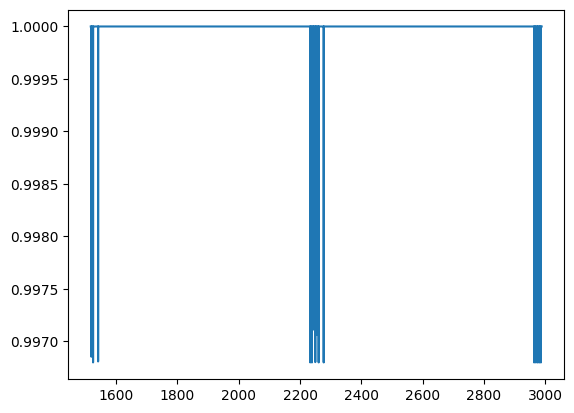

In [126]:
import batman

params = e.calculate_transit_model_params(lc)
time = lc.time.value
# lc = lc.fold(period = e.period, t0 = e.transit_time)
# lc.scatter()
full_params = [e.period, e.transit_time, e.r_planet_over_star, e.sma_over_r_star]
full_params.extend(params)

model = Exoplanet.transit_model(full_params, time)

plot.plot(time, model)
plot.show()